# Phenotype Prediction

### Imports

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [62]:
features_dir = Path("../tests/features")
csv_files = sorted(features_dir.glob("features_*.csv"))
csv_files = [f for f in csv_files if "brain" not in f.name.lower()]

data_list = []
for csv_file in csv_files:
    identifier = csv_file.stem.replace("features_", "")
    df_temp = pd.read_csv(csv_file)
    df_temp["identifier"] = identifier
    data_list.append(df_temp)

df_raw = pd.concat(data_list, ignore_index=True)
df = df_raw.pivot_table(
    index="identifier",
    columns="feature",
    values="value",
    aggfunc="first",
)

phenotype_map = {"h": "healthy", "dr": "diabetes", "g": "glaucoma"}
sample_meta = pd.DataFrame(index=df.index)
sample_meta["sample_suffix"] = sample_meta.index.to_series().astype(str).str.split("_").str[-1]
sample_meta["phenotype"] = sample_meta["sample_suffix"].map(phenotype_map).fillna("unknown")

phenotype_encode = {"healthy": 0, "diabetes": 1, "glaucoma": 2}
y = sample_meta["phenotype"].map(phenotype_encode).values
X = df.values

print(f"Loaded: {X.shape[0]} samples x {X.shape[1]} features")

Loaded: 45 samples x 16 features


### Clean and Scale Features

In [63]:
vt = VarianceThreshold(threshold=0.0)
X = vt.fit_transform(X)

selected_features = df.columns[vt.get_support()]
df = df.loc[:, selected_features]

f"Removed features: {set(df_raw['feature']) - set(selected_features)}, Remaining features: {len(selected_features)}"

"Removed features: {'min_length'}, Remaining features: 15"

In [64]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

df = pd.DataFrame(X, index=df.index, columns=df.columns)
df.head()

feature,fractal_dimension,fractal_dimension_r2,max_degree,max_length,mean_degree,mean_length,mean_tortuosity,num_bifurcations,num_components,num_edges,num_endpoints,num_nodes,std_length,std_tortuosity,total_length
identifier,,,,,,,,,,,,,,,
01_dr,-2.545730,2.675287,0.742781,1.651071,0.811191,1.976634,-0.024314,-1.769195,-1.290039,-1.895982,-2.274192,-2.045422,2.956696,0.032720,-2.425485
01_g,0.035788,0.032226,-1.346291,-1.018640,1.096910,-0.352930,-0.695168,0.159443,-1.806055,0.053284,-0.492088,-0.079784,-0.226860,-0.675420,-0.044423
01_h,0.885821,-1.657930,0.742781,-1.175665,-1.276227,0.282428,-0.431892,0.029535,1.548047,0.185535,0.972413,0.388225,-0.609106,-0.723088,0.980573
02_dr,-0.785755,0.750768,0.742781,0.671302,-0.564425,1.156146,-0.100576,-0.969759,-0.516016,-0.952974,-0.756757,-0.935572,1.134165,-0.055564,-0.690866
02_g,0.710335,-0.797764,0.742781,-1.072854,0.334968,-0.942861,-0.297851,0.858949,-0.258008,0.869790,0.778322,0.869605,-1.005937,-0.053791,0.751521


### Random Forest

In [65]:
rf = RandomForestClassifier(random_state=42)

params = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 5, 10, 20, 25, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "criterion": ["gini", "entropy"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=params,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

rf_grid.fit(X, y)

print(f"Best score: {rf_grid.best_score_}")
print(f"Best params: {rf_grid.best_params_}")

best_rf_model = rf_grid.best_estimator_

Best score: 0.7999999999999999
Best params: {'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 500}


In [66]:
importances = pd.DataFrame(
    {"feature": df.columns, "importance": best_rf_model.feature_importances_}
).sort_values("importance", ascending=False).reset_index(drop=True)
importances

,feature,importance
0,mean_degree,0.145367
1,max_degree,0.115826
2,mean_tortuosity,0.096093
3,mean_length,0.091941
4,max_length,0.087720
5,std_tortuosity,0.079542
6,std_length,0.067002
7,fractal_dimension_r2,0.058042
8,num_endpoints,0.049413
9,num_nodes,0.047731


### Support Vector Machine

In [67]:
svm = SVC()

svm_params = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale", "auto"],
    "degree": [2, 3, 4],
}

svm_grid = GridSearchCV(
    estimator=svm,
    param_grid=svm_params,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)

svm_grid.fit(X, y)

print(f"Best score: {svm_grid.best_score_}")
print(f"Best params: {svm_grid.best_params_}")

best_svm_model = svm_grid.best_estimator_

Best score: 0.8666666666666666
Best params: {'C': 0.1, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}


### Logistic Regression

In [68]:
logreg = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")

logreg_params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "newton-cg", "newton-cholesky", "sag", "saga"],
}

logreg_grid = GridSearchCV(
    estimator=logreg,
    param_grid=logreg_params,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)

logreg_grid.fit(X, y)

print(f"Best score: {logreg_grid.best_score_}")
print(f"Best params: {logreg_grid.best_params_}")

best_logreg_model = logreg_grid.best_estimator_

Best score: 0.888888888888889
Best params: {'C': 0.1, 'solver': 'lbfgs'}


/home/simon/dev/VesSkel/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/simon/dev/VesSkel/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/simon/dev/VesSkel/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/simon/dev/VesSkel/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


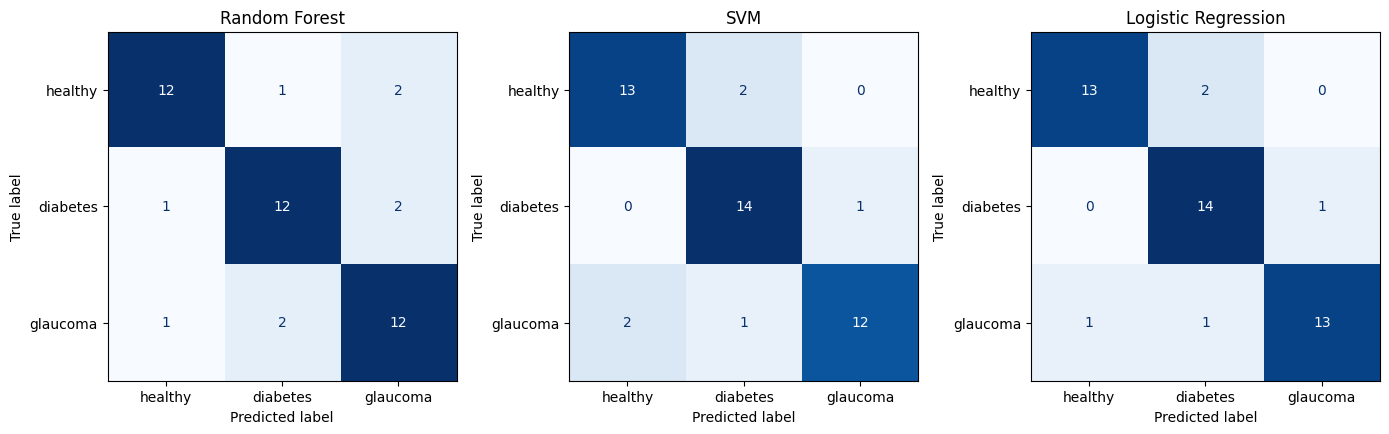

In [78]:
models = [
    ("Random Forest", best_rf_model),
    ("SVM", best_svm_model),
    ("Logistic Regression", best_logreg_model),
]

labels = [name for name, _ in sorted(phenotype_encode.items(), key=lambda kv: kv[1])]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (name, model) in zip(axes, models):
    y_pred = cross_val_predict(model, X, y, cv=cv, n_jobs=-1)
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig("./figures/individual_confusion_matrices.png", dpi=300)
plt.show()


### Voting and Stacking Ensembles

Voting Classifier accuracy: 0.844
Stacking Classifier accuracy: 0.911


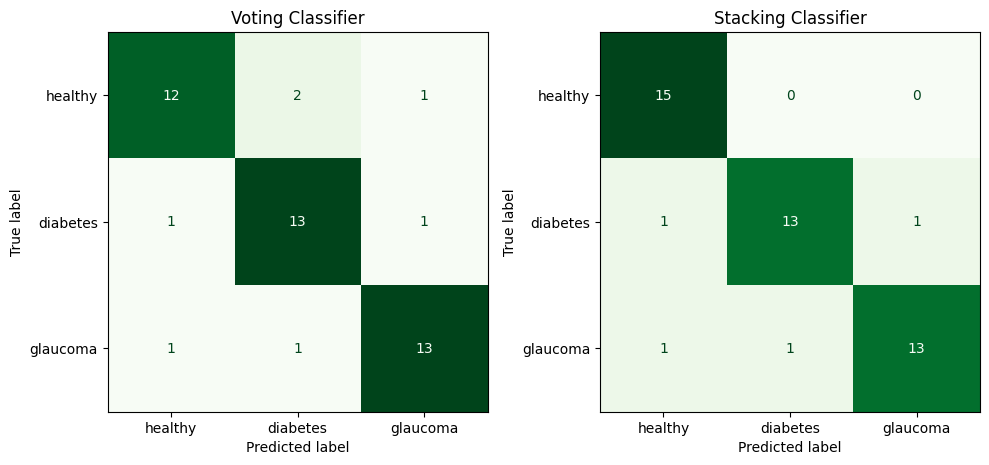

In [76]:
rf = RandomForestClassifier(n_estimators=200, random_state=0)
svm = SVC(probability=True, kernel="rbf", C=1.0, random_state=0)
log = LogisticRegression(max_iter=1000, solver="lbfgs", random_state=0)

ensemble_models = [
    (
        "Voting Classifier",
        VotingClassifier(
            estimators=[("rf", rf), ("svm", svm), ("log", log)],
            voting="hard",
            n_jobs=-1,
        ),
    ),
    (
        "Stacking Classifier",
        StackingClassifier(
            estimators=[("rf", rf), ("svm", svm), ("log", log)],
            final_estimator=LogisticRegression(max_iter=1000, solver="lbfgs"),
            cv=5,
            passthrough=False,
        ),
    ),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (name, model) in zip(axes, ensemble_models):
    y_pred = cross_val_predict(model, X, y, cv=cv, n_jobs=-1)
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap="Greens", colorbar=False)
    ax.set_title(name)
    print(f"{name} accuracy: {(y_pred == y).mean():.3f}")

plt.tight_layout()
plt.savefig("./figures/ensemble_confusion_matrices.png", dpi=300)
plt.show()


### Comparison

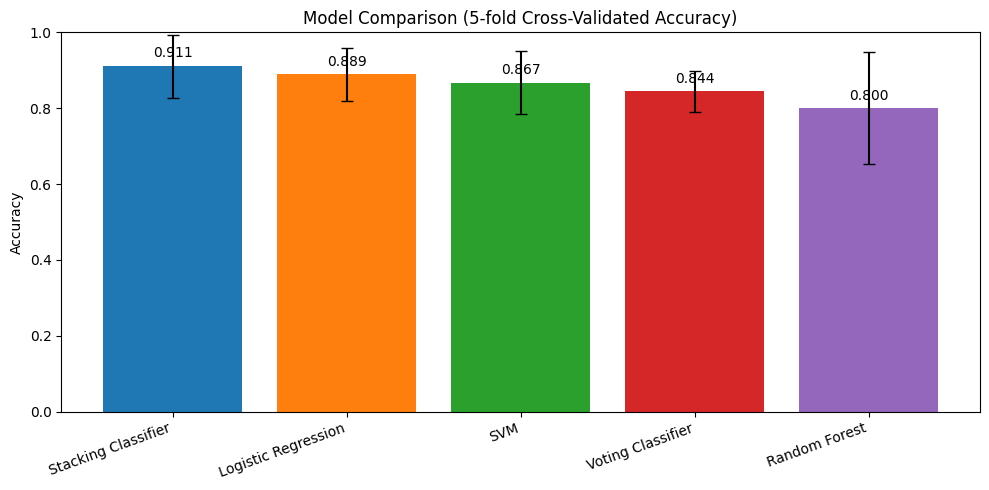

,Model,Mean Accuracy,Std
0,Stacking Classifier,0.911111,0.083148
1,Logistic Regression,0.888889,0.070273
2,SVM,0.866667,0.083148
3,Voting Classifier,0.844444,0.054433
4,Random Forest,0.800000,0.147406


In [82]:
comparison_models = [
    ("Random Forest", best_rf_model),
    ("SVM", best_svm_model),
    ("Logistic Regression", best_logreg_model),
    *ensemble_models,
]

scores = []
for name, model in comparison_models:
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    scores.append(
        {
            "Model": name,
            "Mean Accuracy": cv_scores.mean(),
            "Std": cv_scores.std(),
        }
    )

scores_df = pd.DataFrame(scores).sort_values("Mean Accuracy", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    scores_df["Model"],
    scores_df["Mean Accuracy"],
    yerr=scores_df["Std"],
    capsize=4,
    color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"],
)
ax.set_title("Model Comparison (5-fold Cross-Validated Accuracy)")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")

for i, v in enumerate(scores_df["Mean Accuracy"]):
    ax.text(i, v + 0.015, f"{v:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("./figures/final_model_comparison.png", dpi=300)
plt.show()

scores_df